In [8]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import pandas as pd
import seaborn as sns
from pathlib import Path
Base_dir=Path().resolve()
data_path=Base_dir.parent/"data/processed/customer_churn_features.csv"
#model_path=Base_dir/"models/customer_segmentation.pkl"
#output_path=Base_dir/"data/customer_segments.csv"
df = pd.read_csv(data_path)
X = df[['TotalOrders','ActiveMonth','AvgOrderValue','Recency','PurchaseFrequency']]

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)





`elbow method`

In [3]:
def elbow_method(X_scaled):
    wcss=[]
    for k in range(2,15):
        kmeans=KMeans(n_clusters=k,random_state=42)
        kmeans.fit(X_scaled)
        wcss.append(kmeans.inertia_)
    plt.plot(range(2,15),wcss,marker='o')
    plt.title('Elbow Method')
    plt.xlabel("Number of clusters")
    plt.ylabel("wcss")
    plt.show()

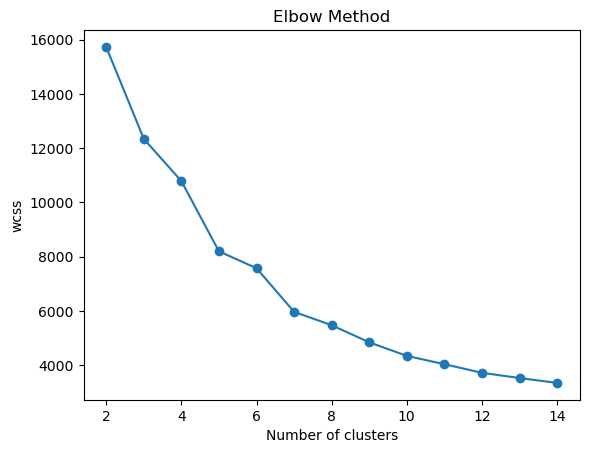

In [4]:
elbow_method(X_scaled)

elbow point b/w 2 and 4

`Silhouette method`

In [5]:
def silhouette_method():
    for k in range(2,15):
        kmeans=KMeans(n_clusters=k,random_state=42)
        labels=kmeans.fit_predict(X_scaled)
        score=silhouette_score(X_scaled,labels)
        print(f"K:-{k}, score:{score}")

In [6]:
silhouette_method()

K:-2, score:0.45695342628291824
K:-3, score:0.3405735911621878
K:-4, score:0.3060124785741745
K:-5, score:0.37540125802013774
K:-6, score:0.3133922692378344
K:-7, score:0.35282857204901985
K:-8, score:0.26136777502368236
K:-9, score:0.29989513778037413
K:-10, score:0.30909467795198614
K:-11, score:0.3224399640750772
K:-12, score:0.319196829386804
K:-13, score:0.3274241116038275
K:-14, score:0.3134824236347665


In [11]:
# from 2 to 4 k=2,k=3,k=4

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X) 
k_values=[2,3,4]
features = [
    'TotalOrders',
    'ActiveMonth',
    'AvgOrderValue',
    'Recency',
    'PurchaseFrequency'
]
for k in k_values:
    print(f"for num of clusters {k}")
    kmeans=KMeans(n_clusters=k,random_state=42)
    df['clusters']=kmeans.fit_predict(X_scaled)
    # Cluster Summary
    print("\nCluster Means:")
    print(df.groupby('clusters')[features].mean())
    
    # Cluster Size
    print("\nCluster Sizes:")
    print(df['clusters'].value_counts())

    

for num of clusters 2

Cluster Means:
          TotalOrders  ActiveMonth  AvgOrderValue     Recency  \
clusters                                                        
0            2.443185     2.202429     386.941979  103.430499   
1           15.129784     7.923461     468.123441   20.532446   

          PurchaseFrequency  
clusters                     
0                  1.098023  
1                  1.735083  

Cluster Sizes:
clusters
0    3705
1     601
Name: count, dtype: int64
for num of clusters 3

Cluster Means:
          TotalOrders  ActiveMonth  AvgOrderValue     Recency  \
clusters                                                        
0            1.444967     1.333020     287.876023  245.260583   
1            3.159503     2.769805     434.507603   44.923268   
2           18.025701     8.663551     434.138096   19.577103   

          PurchaseFrequency  
clusters                     
0                  1.067482  
1                  1.127144  
2                  1.87690

K=2 divides customers into two broad categories such as high and low activity, providing a simple but sharp segmentation. In contrast, K=3 offers a more detailed and meaningful segmentation by separating customers into high-value, medium, and low-engagement groups, which makes it more useful for understanding customer behavior and designing targeted business strategies. so k=3

In [10]:


for k in [2,3,4,5]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    print(k, silhouette_score(X_scaled, labels))

2 0.45695342628291824
3 0.3405735911621878
4 0.3060124785741745
5 0.37540125802013774


score of k=2 is the highest so k=2